In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *
import pandas as pd
from joblib import Parallel, delayed

In [2]:
dp_samples = pd.read_csv('dp_samples.csv')

In [ ]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [4]:
dp_samples_regime1  = read_ids('dp_samples_regime1_ids.txt')
dp_samples_regime2  = read_ids('dp_samples_regime2_ids.txt')
dp_samples_regime3  = read_ids('dp_samples_regime3_ids.txt')
dp_samples_regime4  = read_ids('dp_samples_regime4_ids.txt')
dp_samples_all      = read_ids('dp_samples_ids.txt')

DP1_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dp_samples_regime1)
DP2_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dp_samples_regime2)
DP3_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dp_samples_regime3)
DP4_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dp_samples_regime4)
DP_SPECTRA  = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dp_samples_all)

In [5]:
dp_df_1 = dp_samples[dp_samples['TARGETID'].isin(dp_samples_regime1)].reset_index(drop=True)
dp_df_2 = dp_samples[dp_samples['TARGETID'].isin(dp_samples_regime2)].reset_index(drop=True)
dp_df_3 = dp_samples[dp_samples['TARGETID'].isin(dp_samples_regime3)].reset_index(drop=True)
dp_df_4 = dp_samples[dp_samples['TARGETID'].isin(dp_samples_regime4)].reset_index(drop=True)

In [6]:
dp_df_1['LOGSFR'] = dp_df_1['TARGETID'].map(DP1_SPECTRA.df.set_index('TARGETID')['LOGSFR'])
dp_df_1['LOGM'] = dp_df_1['TARGETID'].map(DP1_SPECTRA.df.set_index('TARGETID')['LOGM'])

dp_df_2['LOGSFR'] = dp_df_2['TARGETID'].map(DP2_SPECTRA.df.set_index('TARGETID')['LOGSFR'])
dp_df_2['LOGM'] = dp_df_2['TARGETID'].map(DP2_SPECTRA.df.set_index('TARGETID')['LOGM'])

dp_df_3['LOGSFR'] = dp_df_3['TARGETID'].map(DP3_SPECTRA.df.set_index('TARGETID')['LOGSFR'])
dp_df_3['LOGM'] = dp_df_3['TARGETID'].map(DP3_SPECTRA.df.set_index('TARGETID')['LOGM'])

dp_df_4['LOGSFR'] = dp_df_4['TARGETID'].map(DP4_SPECTRA.df.set_index('TARGETID')['LOGSFR'])
dp_df_4['LOGM'] = dp_df_4['TARGETID'].map(DP4_SPECTRA.df.set_index('TARGETID')['LOGM'])

dp_samples['LOGSFR'] = dp_samples['TARGETID'].map(DP_SPECTRA.df.set_index('TARGETID')['LOGSFR'])
dp_samples['LOGM'] = dp_samples['TARGETID'].map(DP_SPECTRA.df.set_index('TARGETID')['LOGM'])

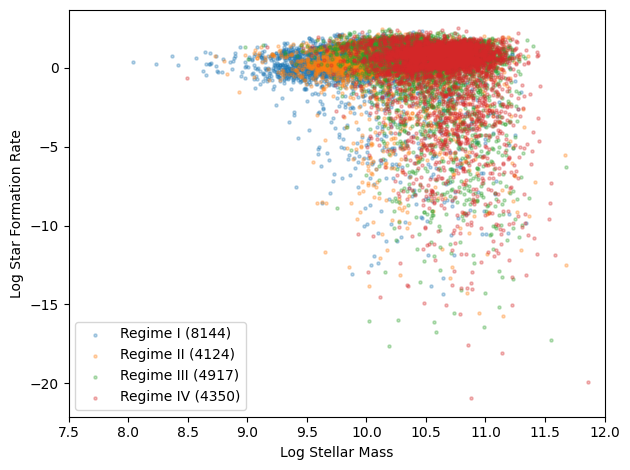

In [49]:
# plt.scatter(dp_samples['LOGM'], dp_samples['LOGSFR'], s=1, alpha=0.5)
plt.scatter(dp_df_1['LOGM'], dp_df_1['LOGSFR'], s=5, label=f'Regime I ({len(dp_df_1)})', alpha=0.3)
plt.scatter(dp_df_2['LOGM'], dp_df_2['LOGSFR'], s=5, label=f'Regime II ({len(dp_df_2)})', alpha=0.3)
plt.scatter(dp_df_3['LOGM'], dp_df_3['LOGSFR'], s=5, label=f'Regime III ({len(dp_df_3)})', alpha=0.3)
plt.scatter(dp_df_4['LOGM'], dp_df_4['LOGSFR'], s=5, label=f'Regime IV ({len(dp_df_4)})', alpha=0.3)
plt.xlabel('Log Stellar Mass')
plt.ylabel('Log Star Formation Rate')
plt.xlim(left=7.5, right=12)
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Jan7/dp_regime_logm_sfr.png')
plt.show()

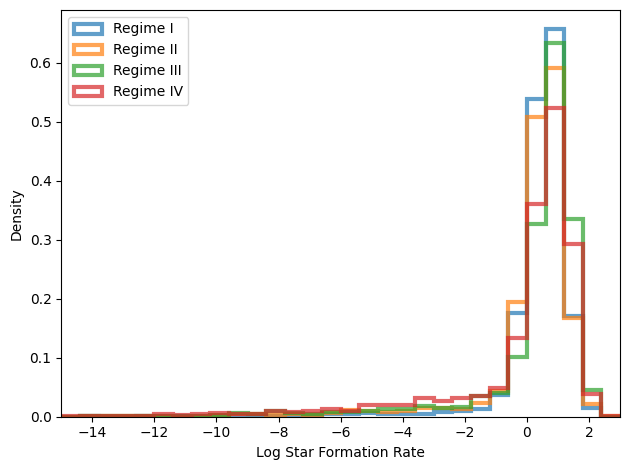

In [50]:
# plt.hist(dp_samples['LOGSFR'], bins=30, alpha=0.7, label='All Samples', histtype='step', linewidth=3, density=True, cumulative=True, range=(-15, 5))
plt.hist(dp_df_1['LOGSFR'], bins=30, alpha=0.7, label='Regime I', histtype='step', linewidth=3, density=True, cumulative=False, range=(-15, 3))
plt.hist(dp_df_2['LOGSFR'], bins=30, alpha=0.7, label='Regime II', histtype='step', linewidth=3, density=True, cumulative=False, range=(-15, 3))
plt.hist(dp_df_3['LOGSFR'], bins=30, alpha=0.7, label='Regime III', histtype='step', linewidth=3, density=True, cumulative=False, range=(-15, 3))
plt.hist(dp_df_4['LOGSFR'], bins=30, alpha=0.7, label='Regime IV', histtype='step', linewidth=3, density=True, cumulative=False, range=(-15, 3))
plt.xlabel('Log Star Formation Rate')
plt.ylabel('Density')
plt.xlim(left=-15, right=3)
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Jan7/dp_regime_logsfr.png')
plt.show()

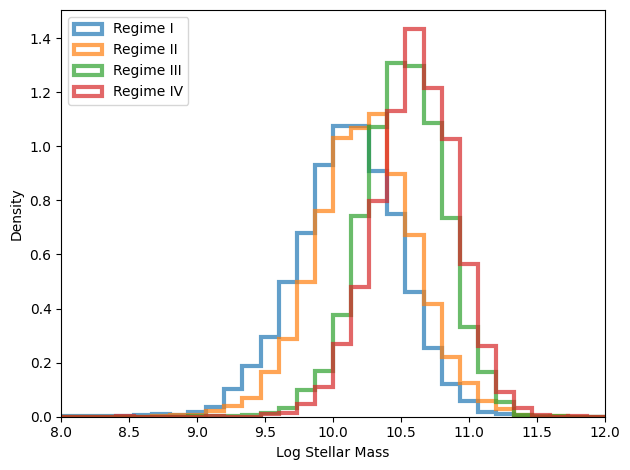

In [51]:
# plt.hist(dp_samples['LOGM'], bins=30, alpha=0.7, label='All Samples', linewidth=3, density=True, range=(8, 12))
plt.hist(dp_df_1['LOGM'], bins=30, alpha=0.7, label='Regime I', histtype='step', linewidth=3, density=True, range=(8, 12), cumulative=False)
plt.hist(dp_df_2['LOGM'], bins=30, alpha=0.7, label='Regime II', histtype='step', linewidth=3, density=True, range=(8, 12), cumulative=False)
plt.hist(dp_df_3['LOGM'], bins=30, alpha=0.7, label='Regime III', histtype='step', linewidth=3, density=True, range=(8, 12), cumulative=False)
plt.hist(dp_df_4['LOGM'], bins=30, alpha=0.7, label='Regime IV', histtype='step', linewidth=3, density=True, range=(8, 12), cumulative=False)
plt.xlabel('Log Stellar Mass')
plt.ylabel('Density')
plt.xlim(left=8, right=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('./figures/Jan7/dp_regime_logm.png')
plt.show()

In [80]:
print(dp_1_example_id := np.random.choice(dp_samples_regime1, 1)[0])
print(dp_2_example_id := np.random.choice(dp_samples_regime2, 1)[0])
print(dp_3_example_id := np.random.choice(dp_samples_regime3, 1)[0])
print(dp_4_example_id := np.random.choice(dp_samples_regime4, 1)[0])

39627776076024793
39627781952244174
39627763648303591
39627745449217039


In [77]:
dp_df_1[dp_df_1['TARGETID'] == 39627806618945177]


,TARGETID,p_value,dv_r,dv_l,delta_dv,sigma_r,sigma_l,OII3726_dp,OII3729_dp,Hbeta_dp,...,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank,dp_count,actual_dp_count,LOGSFR,LOGM
6708,39627806618945177,1.110223e-16,67.992531,-51.586126,119.578657,25.148577,41.35984,False,False,False,...,-1,4,0,1,3,5,5,2,0.671153,10.317522
